# Telecom Network KPI Analysis: Exploration

All data in this project is **synthetic**, generated with `src/generate_data.py`.
In this notebook I load the data, check its quality and look at traffic patterns.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("..") / "data"
sites = pd.read_csv(DATA / "cell_sites.csv")
kpis = pd.read_csv(DATA / "hourly_kpis.csv", parse_dates=["timestamp"])

print(sites.shape, kpis.shape)
sites.head()

(40, 5) (28800, 9)


,cell_id,emirate,area,technology,bandwidth_mhz
0,CELL_001,Abu Dhabi,Khalifa City,4G,20
1,CELL_002,Sharjah,Muwaileh,5G,100
2,CELL_003,Dubai,Downtown,4G,20
3,CELL_004,Dubai,Jebel Ali,4G,20
4,CELL_005,Sharjah,Al Majaz,5G,100


In [2]:
kpis.info()
kpis.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 28800 entries, 0 to 28799
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            28800 non-null  datetime64[us]
 1   cell_id              28800 non-null  str           
 2   connected_users      28800 non-null  int64         
 3   prb_utilization_pct  28800 non-null  float64       
 4   throughput_mbps      28800 non-null  float64       
 5   latency_ms           28800 non-null  float64       
 6   rsrp_dbm             28800 non-null  float64       
 7   call_drop_rate_pct   28800 non-null  float64       
 8   availability_pct     28800 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 2.0 MB


,timestamp,connected_users,prb_utilization_pct,throughput_mbps,latency_ms,rsrp_dbm,call_drop_rate_pct,availability_pct
count,28800,28800.00,28800.00,28800.00,28800.00,28800.00,28800.00,28800.00
mean,2026-09-15 23:30:00,181.62,46.84,90.81,35.40,-87.81,0.33,99.88
min,2026-09-01 00:00:00,0.00,13.60,0.00,6.50,-107.40,0.00,2.20
25%,2026-09-08 11:45:00,109.00,29.80,32.60,15.20,-91.80,0.24,100.00
50%,2026-09-15 23:30:00,161.00,41.30,37.90,36.10,-88.00,0.31,100.00
75%,2026-09-23 11:15:00,233.00,61.50,168.70,43.40,-83.30,0.39,100.00
max,2026-09-30 23:00:00,500.00,100.00,226.80,126.80,-70.80,1.27,100.00
std,NaN,94.21,20.90,69.36,22.69,6.11,0.14,3.09


In [5]:
print(kpis.isna().sum())
print("Duplicated rows:", kpis.duplicated(["timestamp", "cell_id"]).sum())

timestamp              0
cell_id                0
connected_users        0
prb_utilization_pct    0
throughput_mbps        0
latency_ms             0
rsrp_dbm               0
call_drop_rate_pct     0
availability_pct       0
dtype: int64
Duplicated rows: 0


In [6]:
df = kpis.merge(sites, on="cell_id")
df["hour"] = df["timestamp"].dt.hour

df.groupby("technology")[["throughput_mbps", "latency_ms", "call_drop_rate_pct"]].mean().round(2)

,throughput_mbps,latency_ms,call_drop_rate_pct
technology,,,
4G,31.33,50.55,0.33
5G,163.52,16.88,0.32


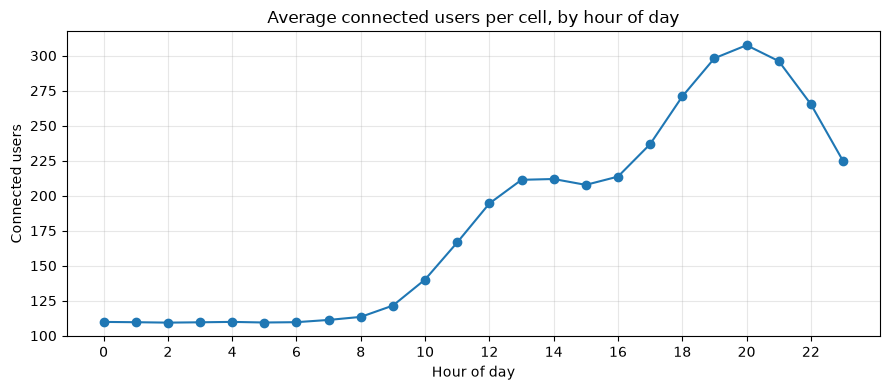

In [7]:
hourly = df.groupby("hour")["connected_users"].mean()

ax = hourly.plot(kind="line", marker="o", figsize=(9, 4))
ax.set_title("Average connected users per cell, by hour of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Connected users")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../images/users_by_hour.png", dpi=150)
plt.show()

## Congestion analysis
A cell is considered congested in an hour when PRB utilization is **80% or higher**.
Outage hours are excluded so they don't distort the averages.

In [8]:
ok = df[df["availability_pct"] == 100]

congestion = (
    ok.assign(congested=ok["prb_utilization_pct"] >= 80)
    .groupby(["cell_id", "emirate", "area", "technology"])
    .agg(
        congested_hours=("congested", "sum"),
        avg_prb_pct=("prb_utilization_pct", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_drop_rate_pct=("call_drop_rate_pct", "mean"),
    )
    .round(2)
    .sort_values("congested_hours", ascending=False)
)

congestion.head(10)

,,,,congested_hours,avg_prb_pct,avg_latency_ms,avg_drop_rate_pct
cell_id,emirate,area,technology,,,,
CELL_038,Sharjah,Muwaileh,4G,195,62.09,65.44,0.39
CELL_032,Dubai,Marina,4G,184,61.72,64.76,0.39
CELL_034,Dubai,Marina,5G,170,60.41,21.71,0.38
CELL_040,Dubai,Jebel Ali,5G,169,60.28,21.68,0.38
CELL_026,Abu Dhabi,Khalifa City,4G,154,59.00,61.52,0.37
CELL_018,Abu Dhabi,Corniche,5G,139,57.21,20.47,0.36
CELL_031,Dubai,Marina,5G,137,56.99,20.17,0.36
CELL_012,Dubai,Marina,4G,136,56.93,58.80,0.35
CELL_002,Sharjah,Muwaileh,5G,134,56.92,20.39,0.36


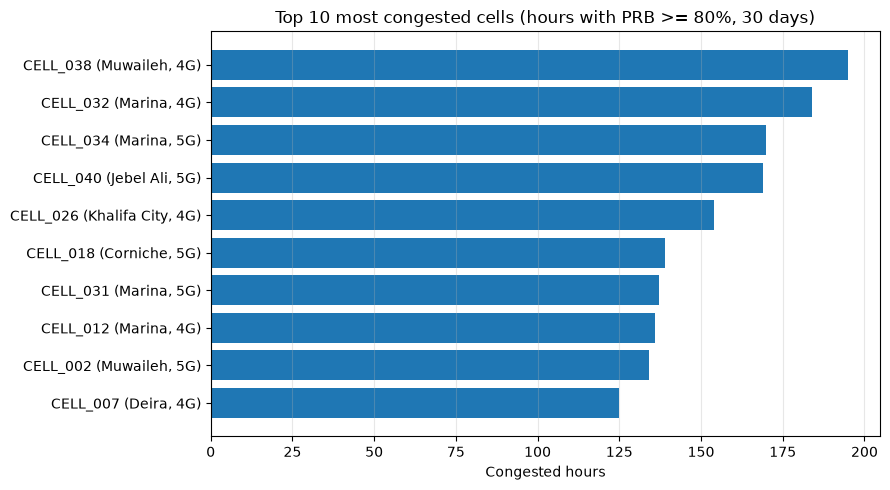

In [9]:
top10 = congestion.head(10).reset_index()
labels = top10["cell_id"] + " (" + top10["area"] + ", " + top10["technology"] + ")"

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, top10["congested_hours"], color="#1f77b4")
ax.invert_yaxis()
ax.set_title("Top 10 most congested cells (hours with PRB >= 80%, 30 days)")
ax.set_xlabel("Congested hours")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../images/top_congested_cells.png", dpi=150)
plt.show()

## Outage detection
An outage is any hour with availability below 100%. Consecutive hours on the same
cell are grouped into a single event.

In [10]:
out = df[df["availability_pct"] < 100].sort_values(["cell_id", "timestamp"]).copy()

new_event = out.groupby("cell_id")["timestamp"].diff() != pd.Timedelta(hours=1)
out["event_id"] = new_event.cumsum()

events = (
    out.groupby("event_id")
    .agg(
        cell_id=("cell_id", "first"),
        area=("area", "first"),
        technology=("technology", "first"),
        start=("timestamp", "min"),
        last_hour=("timestamp", "max"),
        hours_down=("timestamp", "count"),
        avg_availability_pct=("availability_pct", "mean"),
    )
    .round(1)
    .sort_values("start")
    .reset_index(drop=True)
)

print("Outage events detected:", len(events))
events

Outage events detected: 12


C:\Users\julia\AppData\Local\Temp\ipykernel_13636\896473325.py:17: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(1)


,cell_id,area,technology,start,last_hour,hours_down,avg_availability_pct
0,CELL_020,Corniche,4G,2026-09-02 05:00:00,2026-09-02 08:00:00,4,58.3
1,CELL_011,Muwaileh,4G,2026-09-05 00:00:00,2026-09-05 04:00:00,5,24.9
2,CELL_013,Khalifa City,5G,2026-09-05 02:00:00,2026-09-05 03:00:00,2,43.9
3,CELL_033,Jebel Ali,4G,2026-09-05 17:00:00,2026-09-05 20:00:00,4,8.6
4,CELL_009,Marina,4G,2026-09-08 05:00:00,2026-09-08 08:00:00,4,2.2
5,CELL_030,Al Majaz,5G,2026-09-10 21:00:00,2026-09-10 23:00:00,3,41.8
6,CELL_001,Khalifa City,4G,2026-09-10 22:00:00,2026-09-11 01:00:00,4,7.4
7,CELL_001,Khalifa City,4G,2026-09-11 23:00:00,2026-09-12 04:00:00,6,11.5
8,CELL_010,Al Majaz,5G,2026-09-15 00:00:00,2026-09-15 03:00:00,4,10.3
9,CELL_036,Yas Island,5G,2026-09-23 15:00:00,2026-09-23 16:00:00,2,57.8
